In [210]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df=pd.read_csv('customer_churn.csv')
df.head(10)

,age,income,credit_score,transactions_month,avg_purchase_value,days_since_last_login,tenure_months,num_products,gender,region,churn
0,56,NaN,770.887470,29,84.828689,143,90,1,Male,South,1
1,69,53051.954538,622.025467,41,133.943805,72,96,4,Female,East,1
2,46,38654.738821,665.727931,36,114.993023,155,88,3,Male,North,1
3,32,28666.194356,715.281358,29,153.875284,76,110,2,Male,South,0
4,60,40301.406736,NaN,27,115.391031,168,99,2,Male,East,1
5,25,NaN,526.743383,18,104.602284,286,37,4,Female,South,0
6,38,75307.124526,NaN,40,141.636341,84,96,1,Female,North,0
7,56,63224.596354,738.380887,35,155.046767,181,71,3,Male,West,1
8,36,49880.410380,611.369930,33,93.266192,314,33,4,Male,West,1
9,40,72199.162083,829.073950,24,117.556973,296,31,4,Male,East,0


In [211]:
df.isna()

,age,income,credit_score,transactions_month,avg_purchase_value,days_since_last_login,tenure_months,num_products,gender,region,churn
0,False,True,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False
4,False,False,True,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...
995,False,False,False,False,False,False,False,False,False,False,False
996,False,False,False,False,False,False,False,False,False,False,False
997,False,False,False,False,False,False,False,False,False,False,False
998,False,False,False,False,False,False,False,False,False,False,False


In [212]:
df['churn'].value_counts()

churn
1    517
0    483
Name: count, dtype: int64

In [213]:
categorical_cols = df.select_dtypes(include=["object", "category"]).columns
numerical_cols = df.select_dtypes(include=["int64", "float64"]).columns

print("Categorical Columns:")
print(list(categorical_cols))

print("\nNumerical Columns:")
print(list(numerical_cols))

Categorical Columns:
['gender', 'region']

Numerical Columns:
['age', 'income', 'credit_score', 'transactions_month', 'avg_purchase_value', 'days_since_last_login', 'tenure_months', 'num_products', 'churn']


In [214]:
df.describe()

,age,income,credit_score,transactions_month,avg_purchase_value,days_since_last_login,tenure_months,num_products,churn
count,1000.00000,951.000000,950.000000,1000.000000,950.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,43.81900,55354.417513,651.422837,29.842000,119.301574,182.155000,60.394000,3.129000,0.517000
std,14.99103,32708.500386,68.271995,5.453511,39.619144,104.205824,34.163166,1.410088,0.499961
min,18.00000,7271.860691,444.172796,15.000000,-7.068153,0.000000,1.000000,1.000000,0.000000
25%,31.00000,40959.853770,605.096009,26.000000,93.330104,88.000000,31.000000,2.000000,0.000000
50%,44.00000,51298.846812,650.746768,30.000000,119.585761,184.000000,61.000000,3.000000,1.000000
75%,56.00000,61285.465584,697.845647,33.000000,146.374081,273.250000,89.250000,4.000000,1.000000
max,69.00000,254852.478291,873.517530,49.000000,244.516408,364.000000,119.000000,5.000000,1.000000


# Data Preprocessing

In [215]:
df.isnull().sum()

age                       0
income                   49
credit_score             50
transactions_month        0
avg_purchase_value       50
days_since_last_login     0
tenure_months             0
num_products              0
gender                    0
region                    0
churn                     0
dtype: int64

In [216]:
#handling missing values
mean_income=df['income'].mean()
median_income=df['income'].median()
mode_income=df['income'].mode()
print("mean : " ,mean_income)
print("median : " ,median_income)
print("mode : " ,mode_income)


mean :  55354.41751318089
median :  51298.8468120935
mode :  0    254852.478291
Name: income, dtype: float64


In [217]:
# import seaborn as sns
# plt.figure(figsize=(10,6))
# sns.barplot(df['income']
# plt.show()

In [218]:
Q1=df['income'].quantile(0.25)
Q3=df['income'].quantile(0.75)
IQR=Q3-Q1
Lower = Q1 - 1.5*IQR
Upper = Q3 - 1.5*IQR
outliers=df[ (df['income']<Lower) | (df['income']>Upper) ]
outliers

,age,income,credit_score,transactions_month,avg_purchase_value,days_since_last_login,tenure_months,num_products,gender,region,churn
1,69,53051.954538,622.025467,41,133.943805,72,96,4,Female,East,1
2,46,38654.738821,665.727931,36,114.993023,155,88,3,Male,North,1
4,60,40301.406736,NaN,27,115.391031,168,99,2,Male,East,1
6,38,75307.124526,NaN,40,141.636341,84,96,1,Female,North,0
7,56,63224.596354,738.380887,35,155.046767,181,71,3,Male,West,1
...,...,...,...,...,...,...,...,...,...,...,...
995,60,56292.986659,751.728246,26,149.322171,120,93,4,Male,West,0
996,64,36687.617333,556.297594,40,44.289513,172,3,4,Male,South,1
997,62,43438.125495,698.504304,33,132.459634,3,52,2,Male,East,0
998,35,60835.720367,607.589743,49,72.489390,341,74,3,Male,West,1


In [219]:
median_income=round(median_income,7)
median_income

51298.8468121

In [220]:
df['income'].fillna(median_income,inplace=True)
df.isna().sum()

C:\Users\DELL\AppData\Local\Temp\ipykernel_11172\3281962310.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['income'].fillna(median_income,inplace=True)


age                       0
income                    0
credit_score             50
transactions_month        0
avg_purchase_value       50
days_since_last_login     0
tenure_months             0
num_products              0
gender                    0
region                    0
churn                     0
dtype: int64

In [221]:
Q1=df['credit_score'].quantile(0.25)
Q3=df['credit_score'].quantile(0.75)
IQR=Q3-Q1
Lower = Q1 - 1.5*IQR
Upper = Q3 - 1.5*IQR
outliers=df[ (df['credit_score']<Lower) | (df['credit_score']>Upper) ]
outliers

,age,income,credit_score,transactions_month,avg_purchase_value,days_since_last_login,tenure_months,num_products,gender,region,churn
0,56,51298.846812,770.887470,29,84.828689,143,90,1,Male,South,1
1,69,53051.954538,622.025467,41,133.943805,72,96,4,Female,East,1
2,46,38654.738821,665.727931,36,114.993023,155,88,3,Male,North,1
3,32,28666.194356,715.281358,29,153.875284,76,110,2,Male,South,0
7,56,63224.596354,738.380887,35,155.046767,181,71,3,Male,West,1
...,...,...,...,...,...,...,...,...,...,...,...
994,63,48185.777771,633.839354,26,129.585101,222,88,1,Male,South,0
995,60,56292.986659,751.728246,26,149.322171,120,93,4,Male,West,0
997,62,43438.125495,698.504304,33,132.459634,3,52,2,Male,East,0
998,35,60835.720367,607.589743,49,72.489390,341,74,3,Male,West,1


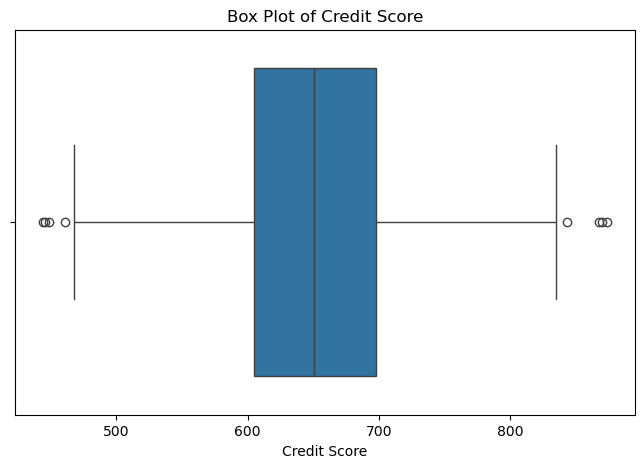

In [222]:
plt.figure(figsize=(8, 5))
sns.boxplot(x=df["credit_score"])
plt.title("Box Plot of Credit Score")
plt.xlabel("Credit Score")
plt.show()

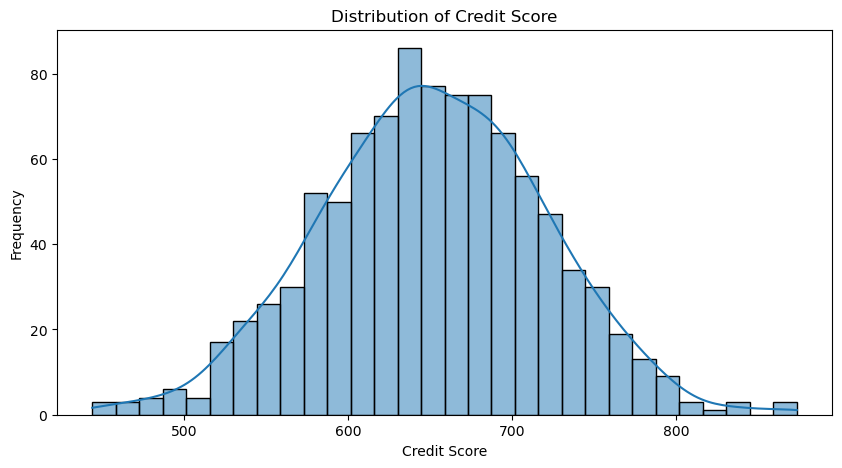

In [223]:
#check distribution of the credict score column
plt.figure(figsize=(10, 5))
sns.histplot(df["credit_score"], kde=True, bins=30)
plt.title("Distribution of Credit Score")
plt.xlabel("Credit Score")
plt.ylabel("Frequency")
plt.show()

In [224]:
mean_credit_score=df['credit_score'].mean()
mean_credit_score


np.float64(651.4228367564334)

In [225]:
mean_credit_score=round(mean_credit_score,7)

In [226]:
df['credit_score']=df['credit_score'].fillna(mean_credit_score)
df.isna().sum()

age                       0
income                    0
credit_score              0
transactions_month        0
avg_purchase_value       50
days_since_last_login     0
tenure_months             0
num_products              0
gender                    0
region                    0
churn                     0
dtype: int64

In [227]:
Q1=df['avg_purchase_value'].quantile(0.25)
Q3=df['avg_purchase_value'].quantile(0.75)
IQR=Q3-Q1
Lower = Q1 - 1.5*IQR
Upper = Q3 - 1.5*IQR
outliers=df[ (df['avg_purchase_value']<Lower) | (df['avg_purchase_value']>Upper) ]
outliers

,age,income,credit_score,transactions_month,avg_purchase_value,days_since_last_login,tenure_months,num_products,gender,region,churn
0,56,51298.846812,770.887470,29,84.828689,143,90,1,Male,South,1
1,69,53051.954538,622.025467,41,133.943805,72,96,4,Female,East,1
2,46,38654.738821,665.727931,36,114.993023,155,88,3,Male,North,1
3,32,28666.194356,715.281358,29,153.875284,76,110,2,Male,South,0
4,60,40301.406736,651.422837,27,115.391031,168,99,2,Male,East,1
...,...,...,...,...,...,...,...,...,...,...,...
994,63,48185.777771,633.839354,26,129.585101,222,88,1,Male,South,0
995,60,56292.986659,751.728246,26,149.322171,120,93,4,Male,West,0
997,62,43438.125495,698.504304,33,132.459634,3,52,2,Male,East,0
998,35,60835.720367,607.589743,49,72.489390,341,74,3,Male,West,1


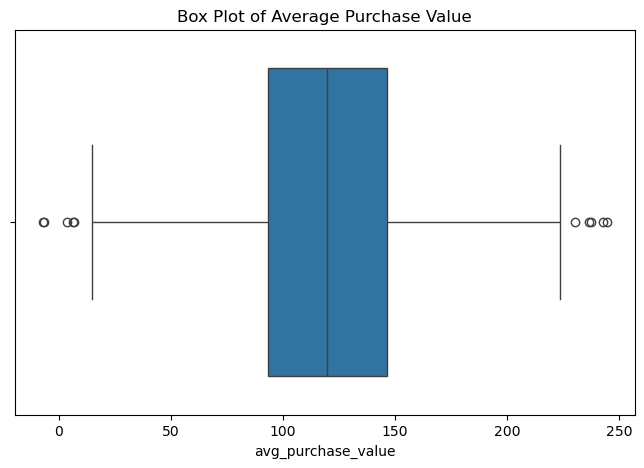

In [228]:
plt.figure(figsize=(8, 5))
sns.boxplot(x=df["avg_purchase_value"])
plt.title("Box Plot of Average Purchase Value")
plt.xlabel("avg_purchase_value")
plt.show()

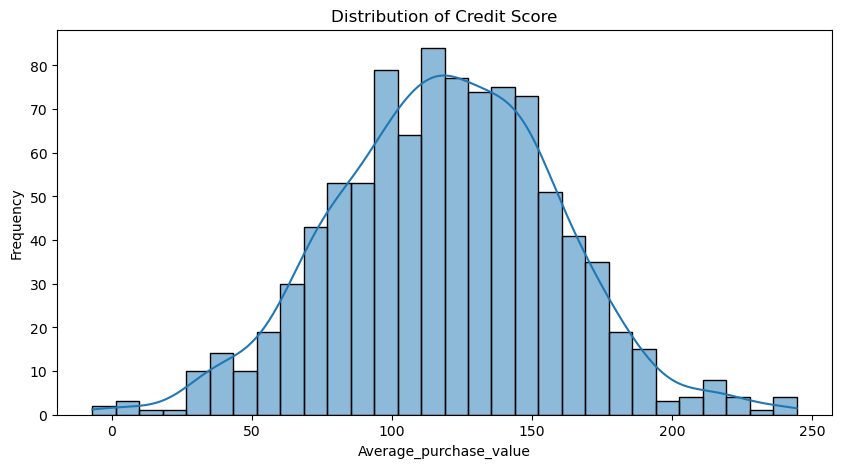

In [229]:
#check distribution of the credict score column
plt.figure(figsize=(10, 5))
sns.histplot(df["avg_purchase_value"], kde=True, bins=30)
plt.title("Distribution of Credit Score")
plt.xlabel("Average_purchase_value")
plt.ylabel("Frequency")
plt.show()

In [230]:
median_avg_purchase_value=df["avg_purchase_value"].median()
median_avg_purchase_value

119.5857610862929

In [231]:
median_avg_purchase_value=round(median_avg_purchase_value,7)
median_avg_purchase_value

119.5857611

In [232]:
df['avg_purchase_value']=df['avg_purchase_value'].fillna(median_avg_purchase_value)
df.isna().sum()

age                      0
income                   0
credit_score             0
transactions_month       0
avg_purchase_value       0
days_since_last_login    0
tenure_months            0
num_products             0
gender                   0
region                   0
churn                    0
dtype: int64

In [233]:
#check unique value in the categorical columns
for col in categorical_cols:
    print(f"Unique value in {col} : {df[col].unique()}")


Unique value in gender : ['Male' 'Female']
Unique value in region : ['South' 'East' 'North' 'West']


In [234]:
df['gender']=df['gender'].replace({"Male":0,"Female":1})
df.head()

C:\Users\DELL\AppData\Local\Temp\ipykernel_11172\2141735532.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['gender']=df['gender'].replace({"Male":0,"Female":1})


,age,income,credit_score,transactions_month,avg_purchase_value,days_since_last_login,tenure_months,num_products,gender,region,churn
0,56,51298.846812,770.887470,29,84.828689,143,90,1,0,South,1
1,69,53051.954538,622.025467,41,133.943805,72,96,4,1,East,1
2,46,38654.738821,665.727931,36,114.993023,155,88,3,0,North,1
3,32,28666.194356,715.281358,29,153.875284,76,110,2,0,South,0
4,60,40301.406736,651.422837,27,115.391031,168,99,2,0,East,1


In [235]:
df = pd.get_dummies(df,columns=["region"],dtype=int)
df.head()

,age,income,credit_score,transactions_month,avg_purchase_value,days_since_last_login,tenure_months,num_products,gender,churn,region_East,region_North,region_South,region_West
0,56,51298.846812,770.887470,29,84.828689,143,90,1,0,1,0,0,1,0
1,69,53051.954538,622.025467,41,133.943805,72,96,4,1,1,1,0,0,0
2,46,38654.738821,665.727931,36,114.993023,155,88,3,0,1,0,1,0,0
3,32,28666.194356,715.281358,29,153.875284,76,110,2,0,0,0,0,1,0
4,60,40301.406736,651.422837,27,115.391031,168,99,2,0,1,1,0,0,0


In [243]:
# changge only boolean columns value into 0 and 1
boolean_cols = df.select_dtypes(include='bool').columns
for col in boolean_cols:
    df[col] = df[col].astype(int)

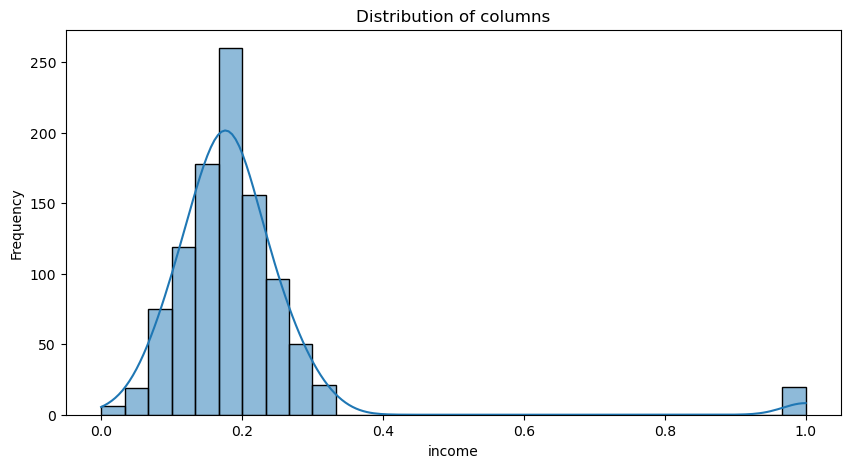

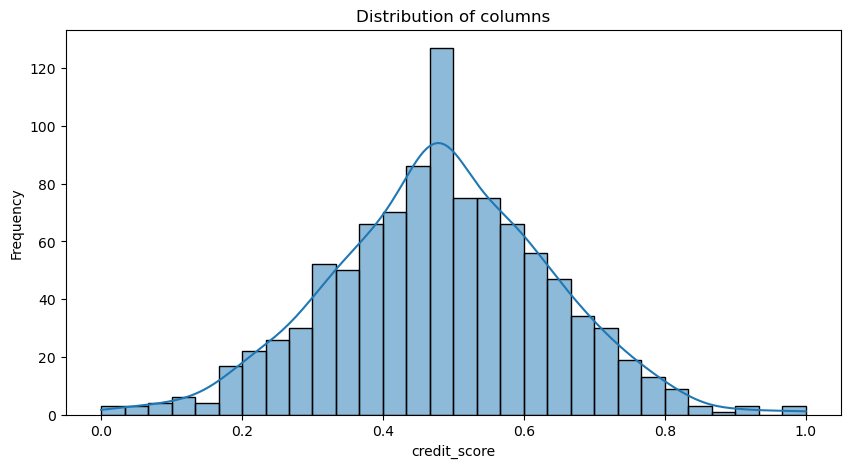

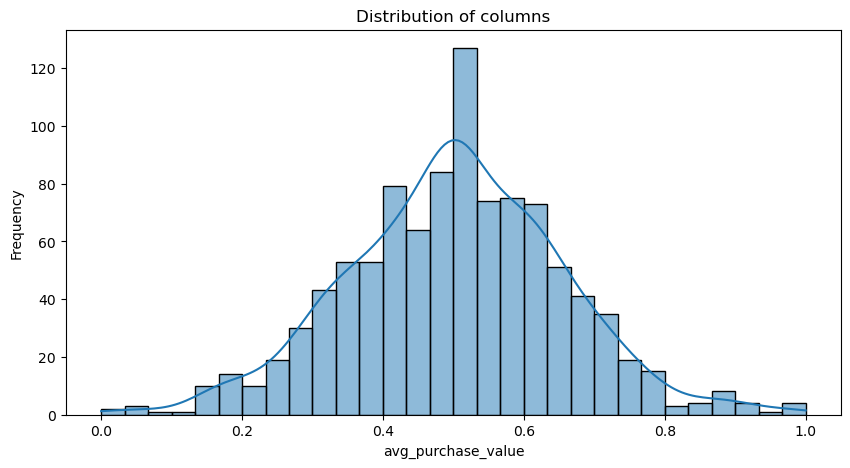

In [244]:
high_scale_cols=['income','credit_score','avg_purchase_value']
for col in high_scale_cols:
    plt.figure(figsize=(10, 5))
    sns.histplot(df[col], kde=True, bins=30)
    plt.title("Distribution of columns")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()
        

In [245]:
from sklearn.preprocessing import MinMaxScaler

scaler=MinMaxScaler()

df[high_scale_cols]=scaler.fit_transform(df[high_scale_cols])

df

,age,income,credit_score,transactions_month,avg_purchase_value,days_since_last_login,tenure_months,num_products,gender,churn,region_East,region_North,region_South,region_West
0,56,0.177829,0.760961,29,0.365272,143,90,1,0,1,0,0,1,0
1,69,0.184910,0.414242,41,0.560495,72,96,4,1,1,1,0,0,0
2,46,0.126758,0.516031,36,0.485170,155,88,3,0,1,0,1,0,0
3,32,0.086414,0.631447,29,0.639719,76,110,2,0,0,0,0,1,0
4,60,0.133409,0.482712,27,0.486752,168,99,2,0,1,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,60,0.198001,0.716337,26,0.621621,120,93,4,0,0,0,0,0,1
996,64,0.118813,0.261153,40,0.204137,172,3,4,0,1,0,0,1,0
997,62,0.146079,0.592371,33,0.554596,3,52,2,0,0,1,0,0,0
998,35,0.216349,0.380619,49,0.316226,341,74,3,0,1,0,0,0,1


In [246]:
df.dtypes

age                        int64
income                   float64
credit_score             float64
transactions_month         int64
avg_purchase_value       float64
days_since_last_login      int64
tenure_months              int64
num_products               int64
gender                     int64
churn                      int64
region_East                int64
region_North               int64
region_South               int64
region_West                int64
dtype: object

In [247]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

X=df.drop('churn',axis=1)
y=df['churn']
print(X)

     age    income  credit_score  transactions_month  avg_purchase_value  \
0     56  0.177829      0.760961                  29            0.365272   
1     69  0.184910      0.414242                  41            0.560495   
2     46  0.126758      0.516031                  36            0.485170   
3     32  0.086414      0.631447                  29            0.639719   
4     60  0.133409      0.482712                  27            0.486752   
..   ...       ...           ...                 ...                 ...   
995   60  0.198001      0.716337                  26            0.621621   
996   64  0.118813      0.261153                  40            0.204137   
997   62  0.146079      0.592371                  33            0.554596   
998   35  0.216349      0.380619                  49            0.316226   
999   55  0.149994      0.759724                  36            0.441900   

     days_since_last_login  tenure_months  num_products  gender  region_East  \
0      

In [250]:
from sklearn.linear_model import LogisticRegression

# load the logistic regression model
model = LogisticRegression(C=10.0, solver='liblinear', max_iter=1000)

# fit the model on the training data
model.fit(X_train, y_train)

# make predictions on the test set
y_pred = model.predict(X_test)

# print the y_pred
print(y_pred)

[1 1 0 1 1 1 1 1 0 1 1 1 0 0 1 0 0 1 1 1 0 1 0 0 1 1 1 0 1 0 1 0 1 1 0 1 1
 1 1 0 1 1 1 0 0 0 1 1 0 0 1 0 1 1 1 0 1 1 0 0 0 1 0 1 0 0 0 1 1 0 0 1 0 1
 1 0 1 0 0 1 1 0 0 0 0 0 1 1 1 1 0 1 1 0 0 0 1 1 1 1 1 1 1 0 1 1 1 1 1 0 0
 1 1 0 0 1 1 1 1 1 0 0 1 1 1 0 1 1 1 0 1 0 1 0 1 1 0 1 1 1 1 1 1 1 1 1 1 1
 0 1 0 1 0 1 1 0 1 1 1 1 0 1 1 0 1 1 1 1 0 1 1 0 1 0 1 0 0 0 0 0 1 0 1 1 1
 0 0 1 1 1 1 0 1 0 1 0 0 0 0 1]


In [251]:
from sklearn.metrics import confusion_matrix

cm=confusion_matrix(y_test,y_pred)
print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[42 62]
 [36 60]]
